In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import time
import numpy as np
import sys
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/Datasets_prepration')
from Simargl import data_preprocessing, evaluate_model, plot_confusion_matrix

le, X, y, X_train, X_test, y_train, y_test, df  = data_preprocessing()
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')
from SHAP import explain_with_shap
from LIME import explain_with_lime





Original Class Distribution:
ALERT
0    5138973
2    5138973
1        571
Name: count, dtype: int64

Class Distribution After Under-Sampling:
ALERT
0    571
1    571
2    571
Name: count, dtype: int64


COMPREHENSIVE FIDELITY EVALUATION ACROSS MODEL ARCHITECTURES

[1/4] Testing: LogisticRegression
  Training model...
  Generating explainers...
  Computing fidelity (100 samples)...
    Progress: 5/100 samples
    Progress: 10/100 samples
    Progress: 15/100 samples
    Progress: 20/100 samples
    Progress: 25/100 samples
    Progress: 30/100 samples
    Progress: 35/100 samples
    Progress: 40/100 samples
    Progress: 45/100 samples
    Progress: 50/100 samples
    Progress: 55/100 samples
    Progress: 60/100 samples
    Progress: 65/100 samples
    Progress: 70/100 samples
    Progress: 75/100 samples
    Progress: 80/100 samples
    Progress: 85/100 samples
    Progress: 90/100 samples
    Progress: 95/100 samples
    Progress: 100/100 samples
  SHAP: 1.0000 ± 0.0000
  LIME: 0.9997 ± 0.0003

[2/4] Testing: DecisionTree
  Training model...
  Generating explainers...
  Computing fidelity (100 samples)...
    Progress: 5/100 samples
    Progress: 10/100 samples
    Progress: 15/100

,Model,SHAP Fidelity,LIME Fidelity,Fidelity Gap
0,LogisticRegression,1.0000 ± 0.0000,0.9997 ± 0.0003,-0.000266
1,DecisionTree,0.7174 ± 0.0000,0.9029 ± 0.1323,0.185498
2,RandomForest,0.7601 ± 0.0497,0.9739 ± 0.0246,0.213820
3,XGBoost,1.0000 ± 0.0000,0.9087 ± 0.0585,-0.091304



STATISTICAL VALIDATION

[1/2] Per-Model Statistical Tests
----------------------------------------------------------------------------------------------------


,Model,Wilcoxon p-value,Significant,Cohen's d,Effect Size,Spearman ρ
0,LogisticRegression,3.8845e-18,✓,-1.1889,large,nan
1,DecisionTree,2.9203e-19,✓,1.9827,large,-0.1269
2,RandomForest,3.6622e-18,✓,5.4555,large,-0.9191
3,XGBoost,3.7646e-18,✓,-2.2065,large,0.8746



[2/2] Overall Summary Across All Models
----------------------------------------------------------------------------------------------------


,Metric,Value
0,SHAP Mean (All Models),0.8694 ± 0.1338
1,LIME Mean (All Models),0.9463 ± 0.0843
2,Mean Difference,0.0769
3,Wilcoxon p-value,8.2272e-12
4,Cohen's d,0.6878
5,Spearman ρ,0.0417 (p=4.0610e-01)
6,Total Samples,400 (4 models × 20 samples)



 Statistical Significance: YES (p < 0.05)
 LIME Outperforms SHAP: YES


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

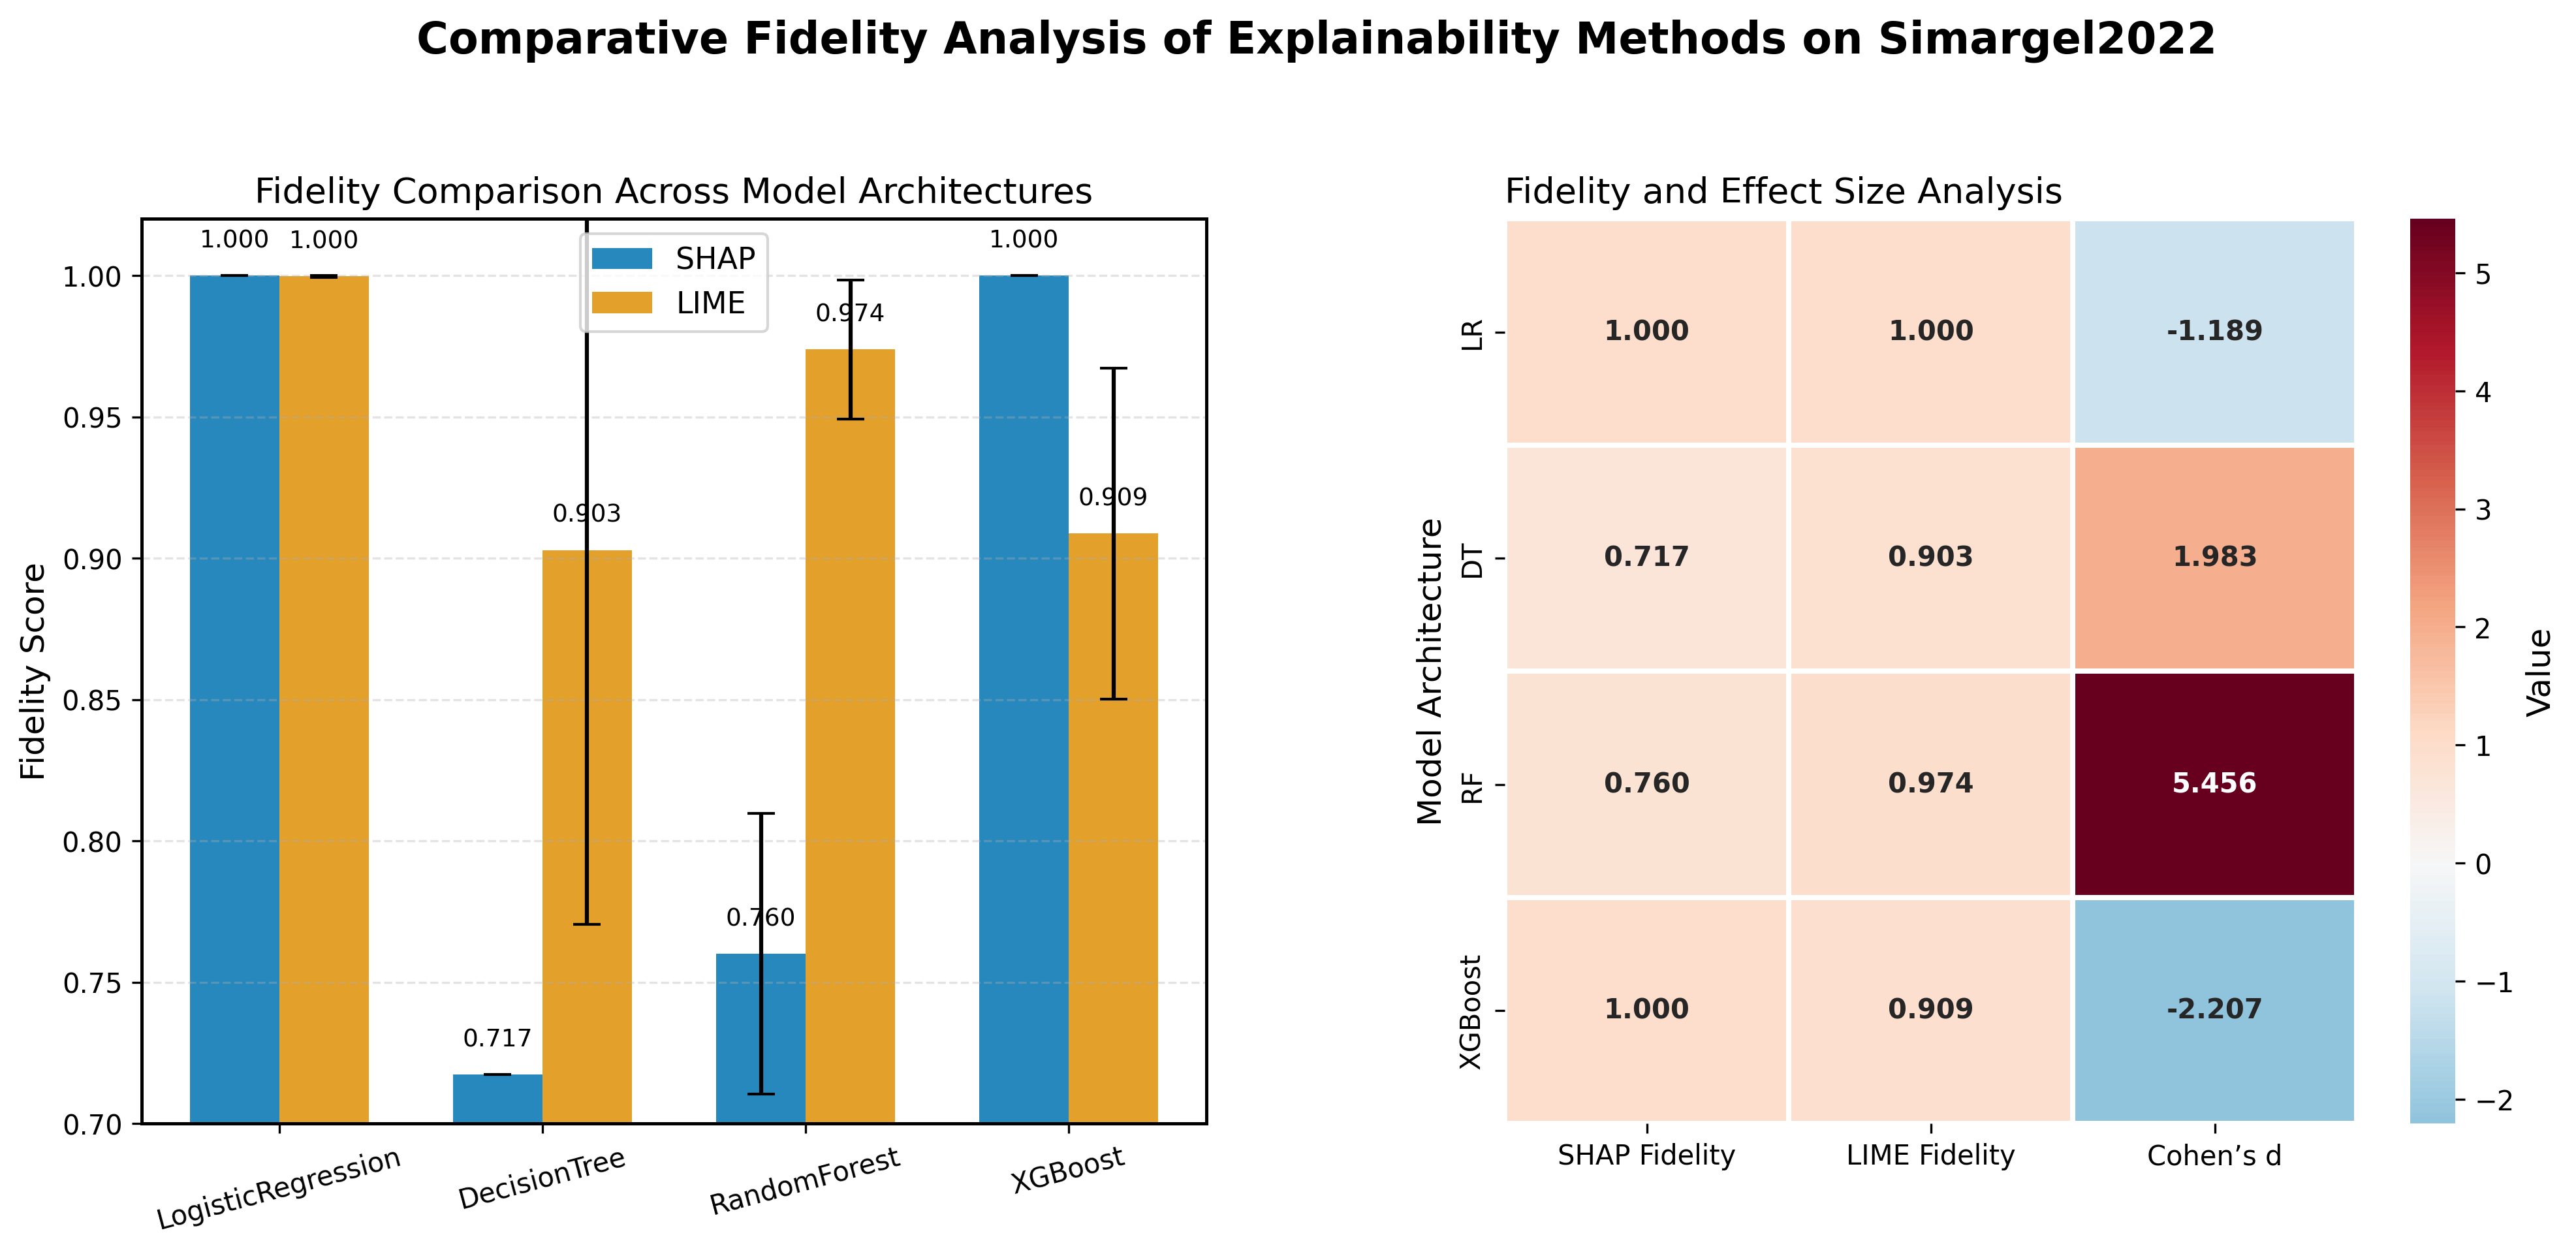


LATEX TABLE FOR PAPER

[TABLE] Model Comparison Results
----------------------------------------------------------------------------------------------------
\begin{table}
\caption{Fidelity Evaluation Across Model Architectures on Simargel2022 Dataset}
\label{tab:model_fidelity_comparison}
\begin{tabular}{lccc}
\toprule
Model & SHAP Fidelity & LIME Fidelity & Fidelity Gap \\
\midrule
LogisticRegression & 1.0000 ± 0.0000 & 0.9997 ± 0.0003 & -0.000266 \\
DecisionTree & 0.7174 ± 0.0000 & 0.9029 ± 0.1323 & 0.185498 \\
RandomForest & 0.7601 ± 0.0497 & 0.9739 ± 0.0246 & 0.213820 \\
XGBoost & 1.0000 ± 0.0000 & 0.9087 ± 0.0585 & -0.091304 \\
\bottomrule
\end{tabular}
\end{table}


[TABLE] Statistical Validation
----------------------------------------------------------------------------------------------------
\begin{table}
\caption{Statistical Significance Tests for Model-Wise Comparisons}
\label{tab:statistical_tests}
\begin{tabular}{lccccc}
\toprule
Model & Wilcoxon p-value & Significant & 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, spearmanr, pearsonr, shapiro, levene, ttest_rel
import warnings
warnings.filterwarnings('ignore')


sys.path.insert(0, '/home/ibibers/XAI_Meth_EVA_for_IDS_For_IeeeTDCS/XAI_Evaluation_Metrices')
sys.path.insert(0, '/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')

from Fidelity import shap_neighborhood_fidelity, lime_neighborhood_fidelity
from SHAP import explain_with_shap
from LIME import explain_with_lime

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 1.2,
})
sns.set_palette("colorblind")

print("="*100)
print("COMPREHENSIVE FIDELITY EVALUATION ACROSS MODEL ARCHITECTURES")
print("="*100)


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=12, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
}

results = []
all_model_shap_fids = {}
all_model_lime_fids = {}


for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"[{list(models.keys()).index(model_name) + 1}/{len(models)}] Testing: {model_name}")
    print('='*80)
    

    print("  Training model...")
    model.fit(X_train, y_train)
    

    print("  Generating explainers...")
    if model_name == 'LogisticRegression':
        shap_values, shap_explainer = explain_with_shap(
            model, X_train, X_test[:200], model_type='linear'
        )
    else:
        shap_values, shap_explainer = explain_with_shap(
            model, X_train, X_test[:200], model_type=None
        )
    
    lime_explainer, _ = explain_with_lime(
        model, X_train, X_test[:200], 
        mode='classification', 
        num_features=76,
        num_samples=5000,
        random_state=42
    )

    print("  Computing fidelity (100 samples)...")
    shap_fids, lime_fids = [], []
    for i in range(100):
        idx = np.random.randint(0, 200)
        instance = X_test.iloc[idx:idx+1].copy()
        
        shap_fid = shap_neighborhood_fidelity(
            shap_explainer, model, instance, 100, 0.05, 'classification', 42
        )
        lime_fid = lime_neighborhood_fidelity(
            lime_explainer, model, instance, 100, 0.05, 'classification', 42
        )
        
        shap_fids.append(shap_fid)
        lime_fids.append(lime_fid)
        
        if (i + 1) % 5 == 0:
            print(f"    Progress: {i + 1}/100 samples")
    

    all_model_shap_fids[model_name] = shap_fids
    all_model_lime_fids[model_name] = lime_fids
    
    results.append({
        'Model': model_name,
        'SHAP Fidelity': f"{np.mean(shap_fids):.4f} ± {np.std(shap_fids):.4f}",
        'LIME Fidelity': f"{np.mean(lime_fids):.4f} ± {np.std(lime_fids):.4f}",
        'SHAP Mean': np.mean(shap_fids),
        'SHAP Std': np.std(shap_fids),
        'LIME Mean': np.mean(lime_fids),
        'LIME Std': np.std(lime_fids),
        'Fidelity Gap': np.mean(lime_fids) - np.mean(shap_fids)
    })
    
    print(f"  SHAP: {np.mean(shap_fids):.4f} ± {np.std(shap_fids):.4f}")
    print(f"  LIME: {np.mean(lime_fids):.4f} ± {np.std(lime_fids):.4f}")


df_results = pd.DataFrame(results)


print("\n" + "="*100)
print("MODEL COMPARISON RESULTS")
print("="*100)
display(df_results[['Model', 'SHAP Fidelity', 'LIME Fidelity', 'Fidelity Gap']])



print("\n" + "="*100)
print("STATISTICAL VALIDATION")
print("="*100)


statistical_results = []

for model_name in models.keys():
    shap_fids = all_model_shap_fids[model_name]
    lime_fids = all_model_lime_fids[model_name]

    wilcox_result = wilcoxon(shap_fids, lime_fids, alternative='two-sided')

    mean_diff = np.mean(lime_fids) - np.mean(shap_fids)
    pooled_std = np.sqrt((np.var(shap_fids) + np.var(lime_fids)) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

    rho, p_rho = spearmanr(shap_fids, lime_fids)
    
    statistical_results.append({
        'Model': model_name,
        'Wilcoxon p-value': f"{wilcox_result.pvalue:.4e}",
        'Significant': '✓' if wilcox_result.pvalue < 0.05 else '✗',
        "Cohen's d": f"{cohens_d:.4f}",
        'Effect Size': (
            "negligible" if abs(cohens_d) < 0.2 else
            "small" if abs(cohens_d) < 0.5 else
            "medium" if abs(cohens_d) < 0.8 else
            "large"
        ),
        'Spearman ρ': f"{rho:.4f}"
    })

df_stats = pd.DataFrame(statistical_results)
print("\n[1/2] Per-Model Statistical Tests")
print("-"*100)
display(df_stats)

print("\n[2/2] Overall Summary Across All Models")
print("-"*100)

all_shap = [fid for fids in all_model_shap_fids.values() for fid in fids]
all_lime = [fid for fids in all_model_lime_fids.values() for fid in fids]

overall_wilcox = wilcoxon(all_shap, all_lime, alternative='two-sided')
overall_rho, overall_p_rho = spearmanr(all_shap, all_lime)

overall_mean_diff = np.mean(all_lime) - np.mean(all_shap)
overall_pooled_std = np.sqrt((np.var(all_shap) + np.var(all_lime)) / 2)
overall_cohens_d = overall_mean_diff / overall_pooled_std

summary_stats = {
    'Metric': [
        'SHAP Mean (All Models)',
        'LIME Mean (All Models)',
        'Mean Difference',
        'Wilcoxon p-value',
        "Cohen's d",
        'Spearman ρ',
        'Total Samples'
    ],
    'Value': [
        f"{np.mean(all_shap):.4f} ± {np.std(all_shap):.4f}",
        f"{np.mean(all_lime):.4f} ± {np.std(all_lime):.4f}",
        f"{overall_mean_diff:.4f}",
        f"{overall_wilcox.pvalue:.4e}",
        f"{overall_cohens_d:.4f}",
        f"{overall_rho:.4f} (p={overall_p_rho:.4e})",
        f"{len(all_shap)} (4 models × 20 samples)"
    ]
}

df_overall_stats = pd.DataFrame(summary_stats)
display(df_overall_stats)

print(f"\n Statistical Significance: {'YES (p < 0.05)' if overall_wilcox.pvalue < 0.05 else 'NO (p ≥ 0.05)'}")
print(f" LIME Outperforms SHAP: {'YES' if overall_mean_diff > 0 else 'NO'}")



fig, axs = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.28})







ax = axs[0]
x, w = np.arange(len(df_results)), 0.34

for dx, method in [(-w/2, 'SHAP'), (w/2, 'LIME')]:
    ax.bar(
        x + dx,
        df_results[f'{method} Mean'],
        w,
        yerr=df_results[f'{method} Std'],
        label=method,
        capsize=5,
        alpha=0.85
    )
    for i, v in enumerate(df_results[f'{method} Mean']):
        ax.text(i + dx, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

ax.set(
    xticks=x,
    xticklabels=df_results['Model'],
    ylabel='Fidelity Score',
    ylim=(0.70, 1.02),
    title=' Fidelity Comparison Across Model Architectures'
)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(fontsize=11)


rows = [
    [
        np.mean(all_model_shap_fids[m]),
        np.mean(all_model_lime_fids[m]),
        (np.mean(all_model_lime_fids[m]) - np.mean(all_model_shap_fids[m])) /
        np.sqrt((np.var(all_model_shap_fids[m]) + np.var(all_model_lime_fids[m])) / 2)
        if np.var(all_model_shap_fids[m]) + np.var(all_model_lime_fids[m]) > 0 else 0
    ]
    for m in models
]

effect_df = pd.DataFrame(
    rows,
    columns=['SHAP Fidelity', 'LIME Fidelity', "Cohen’s d"],
    index=[m.replace('LogisticRegression','LR')
             .replace('DecisionTree','DT')
             .replace('RandomForest','RF') for m in models]
)

sns.heatmap(
    effect_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    linewidths=1.5, linecolor='white',
    cbar_kws={'label': 'Value'},
    annot_kws={'fontsize': 10, 'fontweight': 'bold'},
    ax=axs[1]
)

axs[1].set_title('Fidelity and Effect Size Analysis', loc='left')
axs[1].set_ylabel('Model Architecture')


fig.suptitle(
    'Comparative Fidelity Analysis of Explainability Methods on CICIDS2017',
    fontsize=16, fontweight='bold', y=1.05
)

plt.tight_layout()
plt.show()


print("\n" + "="*100)
print("LATEX TABLE FOR PAPER")
print("="*100)

print("\n[TABLE] Model Comparison Results")
print("-"*100)
print(df_results[['Model', 'SHAP Fidelity', 'LIME Fidelity', 'Fidelity Gap']].to_latex(
    index=False,
    caption="Fidelity Evaluation Across Model Architectures on CICIDS2017 Dataset",
    label="tab:model_fidelity_comparison",
    column_format='lccc',
    escape=False
))

print("\n[TABLE] Statistical Validation")
print("-"*100)
print(df_stats.to_latex(
    index=False,
    caption="Statistical Significance Tests for Model-Wise Comparisons",
    label="tab:statistical_tests",
    column_format='lccccc',
    escape=False
))



print("\n" + "="*100)
print("EVALUATION COMPLETE - SUMMARY")
print("="*100)
print(f"Models Tested: {len(models)}")
print(f"Total Samples: {len(all_shap)} ({len(models)} models × 20 samples)")
print(f"SHAP Mean Fidelity: {np.mean(all_shap):.4f} ± {np.std(all_shap):.4f}")
print(f"LIME Mean Fidelity: {np.mean(all_lime):.4f} ± {np.std(all_lime):.4f}")
print(f"Mean Improvement (LIME > SHAP): {overall_mean_diff:.4f} ({100*overall_mean_diff/np.mean(all_shap):.2f}%)")
print(f"Statistical Significance: p = {overall_wilcox.pvalue:.4e} ({'< 0.05 ' if overall_wilcox.pvalue < 0.05 else '≥ 0.05'})")
print(f"Effect Size (Cohen's d): {overall_cohens_d:.4f}")
print(f"Correlation (Spearman ρ): {overall_rho:.4f}")
print("="*100)
print("\n ALL ANALYSES COMPLETE !\n")